<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/Gan_exp3_postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9070 - loss: 0.3121 - val_accuracy: 0.9584 - val_loss: 0.1386
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9550 - loss: 0.1463 - val_accuracy: 0.9695 - val_loss: 0.1055
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9658 - loss: 0.1115 - val_accuracy: 0.9733 - val_loss: 0.0864
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9703 - loss: 0.0943 - val_accuracy: 0.9712 - val_loss: 0.0941
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.0800 - val_accuracy: 0.9719 - val_loss: 0.0940
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9442 - loss: 0.1897 - val_accuracy: 0.9759 - val_loss: 0.0841
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9806 - loss: 0.0639 - val_accuracy: 0.9822 - val_loss: 0.0620
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9866 - loss: 0.0431 - val_accuracy: 0.9816 - val_loss: 0.0617
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9903 - loss: 0.0305 - val_accuracy: 0.9833 - val_loss: 0.0589
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9924 - loss: 0.0224 - val_accuracy: 0.9841 - val_loss: 0.0570
DNN Accuracy: 0.9739999771118164
CNN Accuracy: 0.9855999946594238


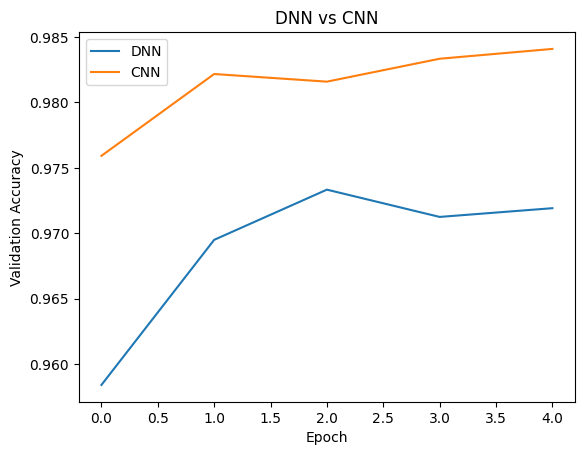

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# DNN
dnn = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

dnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

dnn_history = dnn.fit(
    x_train, y_train, epochs=5,
    validation_split=0.2, verbose=1
)

# CNN
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn_history = cnn.fit(
    x_train[..., None], y_train, epochs=5,
    validation_split=0.2, verbose=1
)

# Compare test accuracy
dnn_acc = dnn.evaluate(x_test, y_test, verbose=0)[1]
cnn_acc = cnn.evaluate(x_test[..., None], y_test, verbose=0)[1]

print("DNN Accuracy:", dnn_acc)
print("CNN Accuracy:", cnn_acc)

# Plot validation accuracy
plt.plot(dnn_history.history['val_accuracy'], label='DNN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("DNN vs CNN")
plt.legend()
plt.show()